In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_circles

In [2]:
x, y = make_circles(n_samples=750, factor=0.3, noise=0.1)

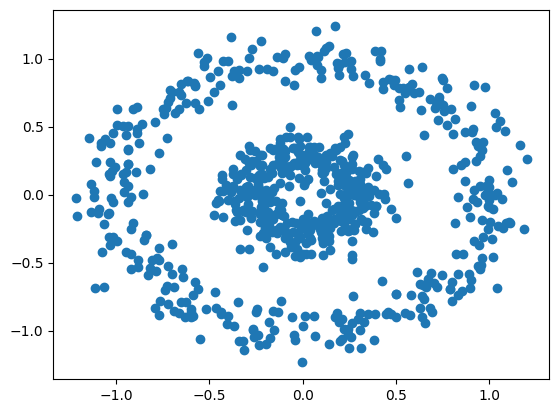

In [3]:
plt.scatter(x[:,0],x[:,1])

In [4]:
scaler = StandardScaler()
sc_x = scaler.fit_transform(x)

In [5]:
n_neighbors_list = [10, 20, 30, 40, 50, 60]
contamination_list = [0.02, 0.05, 0.08, 0.1]

best_score = -np.inf
best_params = {}
best_labels = None
best_scores = None

for n in n_neighbors_list:
    for c in contamination_list:
        temp = LocalOutlierFactor(n_neighbors=n, contamination=c)
        labels = temp.fit_predict(sc_x)
        scores = temp.negative_outlier_factor_

        # Higher (less negative) is better
        avg_score = scores[labels == -1].mean()

        if avg_score > best_score:
            best_score = avg_score
            best_params = {'n_neighbors': n, 'contamination': c}
            best_labels = labels
            best_scores = scores

In [6]:
print("Best Parameters:")
print(best_params)

Best Parameters:
{'n_neighbors': 60, 'contamination': 0.1}


In [7]:
temp = LocalOutlierFactor(n_neighbors=50, contamination=0.1)
labels = temp.fit_predict(sc_x)

In [8]:
labels

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1,
       -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [9]:
outlier_mask = labels == -1
core_mask = labels != -1

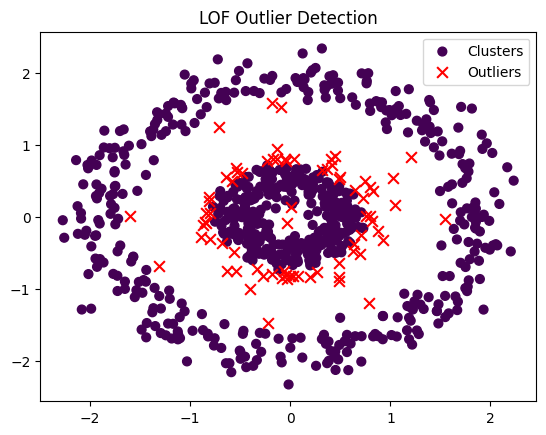

In [10]:
plt.scatter(sc_x[core_mask, 0], sc_x[core_mask, 1], c=labels[core_mask], cmap='viridis', s=40, label='Clusters')
plt.scatter(sc_x[outlier_mask, 0], sc_x[outlier_mask, 1], c='red', marker='x', s=60, label='Outliers')
plt.title('LOF Outlier Detection')
plt.legend()
plt.show()